### Python dependencies

```
qiskit[visualization]
qiskit_finance
```

In [1]:
from math import *
from scipy.stats import norm
import matplotlib.pyplot as plt
#%matplotlib inline

# European option pricing

In [2]:
strike = 100
rate = 0.02 # risk-free rate
sigma = 0.2 # volatility
maturity = 1.0 # time to maturity in years
s0 = 102 # current price

In [3]:
# Call option
d1 = (log(s0/strike)+(rate+sigma**2/2)*maturity)/(sigma*sqrt(maturity))
d2 = d1-sigma*sqrt(maturity)
call_price = s0*norm.cdf(d1)-strike*exp(-rate*maturity)*norm.cdf(d2)
print(f"call: {call_price}")

# Put option
put_price = -s0*norm.cdf(-d1)+strike*exp(-rate*maturity)*norm.cdf(-d2)
print(f"put: {put_price}")

call: 10.113115861217295
put: 6.132983191892826


# Monte-Carlo

In [4]:
import numpy as np

In [5]:
np.random.seed(2021)

In [6]:
trading_days = 252 # per year
mc_paths = 1000

In [7]:
def run_mc(s0, rate, sigma, maturity, steps, count):
    dt = maturity/steps
    paths = np.zeros((steps+1, count), np.float64)
    paths[0] = s0
    for t in range(1, steps+1):
        rand = np.random.standard_normal(count)
        paths[t] = paths[t-1]*np.exp((rate-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*rand)
    return paths

In [8]:
steps = int(trading_days*maturity)
print(f"steps: {steps}")
paths = run_mc(s0, rate, sigma, maturity, steps, mc_paths)

st = np.average(paths[-1])
print(f"MC st: {st}")

call_payoff = np.exp(-rate*maturity)*np.average(np.maximum(0,paths[-1]-strike))
print(f"MC call: {call_payoff}")

steps: 252
MC st: 104.26007260445141
MC call: 10.141584636553787


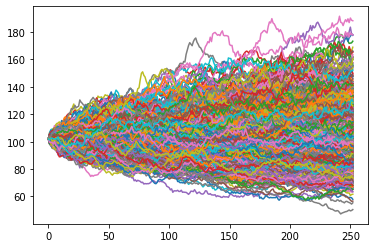

In [9]:
for p in paths.T:
    plt.plot(p)
plt.show()

# Quantum: Phase encoding
- 3 qubits (2^3 states)
- all outcomes have same amplitude, probability
- each state has a different phase
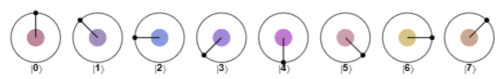

# Quantum: Amplitude encoding
- Must encode values so that: Σ amplitude² = 1

In [10]:
from qiskit import QuantumCircuit, Aer, assemble, transpile, execute, BasicAer
from math import pi
from qiskit.visualization import plot_bloch_multivector, plot_histogram, plot_state_qsphere, plot_state_paulivec
from qiskit_finance.circuit.library import LogNormalDistribution

In [11]:
# q qubits => 2**q values
qubits = 4

In [12]:
shots = 8192

## Constant function
- All outcomes have the same probability

In [13]:
qc = QuantumCircuit(qubits)
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.measure_all()
qc.draw()

┌───┐ ░ ┌─┐         
   q_0: ┤ H ├─░─┤M├─────────
        ├───┤ ░ └╥┘┌─┐      
   q_1: ┤ H ├─░──╫─┤M├──────
        ├───┤ ░  ║ └╥┘┌─┐   
   q_2: ┤ H ├─░──╫──╫─┤M├───
        ├───┤ ░  ║  ║ └╥┘┌─┐
   q_3: ┤ H ├─░──╫──╫──╫─┤M├
        └───┘ ░  ║  ║  ║ └╥┘
meas: 4/═════════╩══╩══╩══╩═
                 0  1  2  3

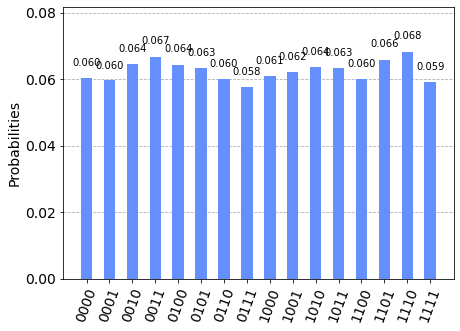

In [14]:
backend = Aer.get_backend('qasm_simulator')
job = execute(qc, backend, shots=shots)
result = job.result()

counts = result.get_counts(qc)
#print(f"counts: {counts}")
plot_histogram(counts)

### Simulators
https://qiskit.org/documentation/tutorials/simulators/1_aer_provider.html

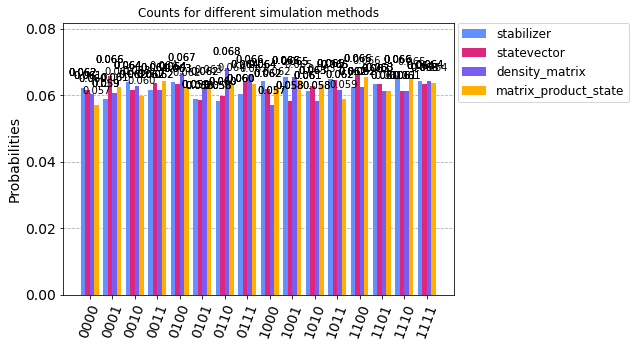

In [15]:
# Stabilizer simulation method
sim_stabilizer = Aer.get_backend('aer_simulator_stabilizer')
job_stabilizer = sim_stabilizer.run(qc, shots=shots)
counts_stabilizer = job_stabilizer.result().get_counts(0)

# Statevector simulation method
sim_statevector = Aer.get_backend('aer_simulator_statevector')
job_statevector = sim_statevector.run(qc, shots=shots)
counts_statevector = job_statevector.result().get_counts(0)

# Density Matrix simulation method
sim_density = Aer.get_backend('aer_simulator_density_matrix')
job_density = sim_density.run(qc, shots=shots)
counts_density = job_density.result().get_counts(0)

# Matrix Product State simulation method
sim_mps = Aer.get_backend('aer_simulator_matrix_product_state')
job_mps = sim_mps.run(qc, shots=shots)
counts_mps = job_mps.result().get_counts(0)

plot_histogram([counts_stabilizer, counts_statevector, counts_density, counts_mps],
               title='Counts for different simulation methods',
               legend=['stabilizer', 'statevector',
                       'density_matrix', 'matrix_product_state'])

## Linear function
- Attempt to encode values 0,1,2,3 in 2 qubits
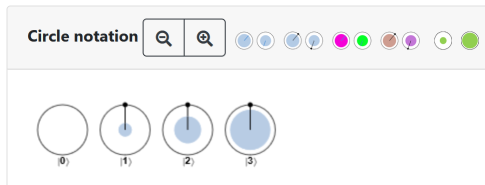

### QCEngine equivalent
c.f. https://oreilly-qc.github.io/# Ex 9-3: QRAM
```
var vector = [0.0, 1.0, 2.0, 3.0];

var num_qubits = 2;
qc.reset(num_qubits);
var amp_enc_reg = qint.new(num_qubits, 'amp_enc_reg');
amplitude_encode(vector, amp_enc_reg);

function amplitude_encode(vec, qreg)
{
    var num_qubits = qreg.numBits;
    qreg.write(0);
    var reg_mask = 3;//(1 << num_qubits) - 1;
    var vec_mag_sqr = 0.0;
    for (var i = 0; i < vec.length; ++i)
        vec_mag_sqr += vec[i] * vec[i];
    var remaining_power = vec_mag_sqr;

    for (var i = 1; i < vec.length; ++i)
    {
        var power = vec[i] * vec[i];
        var top_bit = 1;
        while ((top_bit << 1) <= i)
            top_bit <<= 1;

        var cond_bits = reg_mask ^ top_bit;
        var split = power / remaining_power;
        var theta = 2 * Math.asin(Math.sqrt(split)) * 180 / Math.PI;
        var cnot_mask = i ^ top_bit;

        qc.cnot(cnot_mask, top_bit);
        qc.not(cond_bits);
        qc.roty(theta, top_bit, cond_bits);
        qc.not(cond_bits);
        qc.cnot(cnot_mask, top_bit);
        remaining_power -= power;
    }
}
```

In [16]:
def amplitude_encoding_circuit():
    qc = QuantumCircuit(2)
    # values encoded in qubits amplitudes
    values = [0,1,2,3]
    squares = [x**2 for x in values]
    remain = sum(squares)

    for i in range(1,4):
        qubit=i//2
        theta = 2*asin(sqrt(squares[i]/remain))
        qc.barrier() # for readability
        qc.x(1-qubit)
        qc.barrier() # for readability

        # custom controlled ry rotation
        # c.f. https://qiskit.org/textbook/ch-gates/more-circuit-identities.html
        qc.ry(theta/2,qubit)
        qc.cx(1-qubit,qubit)
        qc.ry(-theta/2,qubit)
        qc.cx(1-qubit,qubit)

        qc.barrier() # for readability
        qc.x(1-qubit)
        remain = remain - squares[i]
        if i>1:
            qc.cx(1,0)

    return qc

qc = amplitude_encoding_circuit()
qc.measure_all()
qc.draw()

░       ░ ┌─────────────┐┌───┐┌──────────────┐┌───┐ ░       ░ ┌───┐ ░ »
   q_0: ─░───────░─┤ RY(0.27055) ├┤ X ├┤ RY(-0.27055) ├┤ X ├─░───────░─┤ X ├─░─»
         ░ ┌───┐ ░ └─────────────┘└─┬─┘└──────────────┘└─┬─┘ ░ ┌───┐ ░ └───┘ ░ »
   q_1: ─░─┤ X ├─░──────────────────■────────────────────■───░─┤ X ├─░───────░─»
         ░ └───┘ ░                                           ░ └───┘ ░       ░ »
meas: 2/═══════════════════════════════════════════════════════════════════════»
                                                                               »
«                                              ░ ┌───┐┌───┐ ░ ┌───┐ ░ »
«   q_0: ───────────────■──────────────────■───░─┤ X ├┤ X ├─░─┤ X ├─░─»
«        ┌───────────┐┌─┴─┐┌────────────┐┌─┴─┐ ░ └───┘└─┬─┘ ░ └───┘ ░ »
«   q_1: ┤ RY(0.588) ├┤ X ├┤ RY(-0.588) ├┤ X ├─░────────■───░───────░─»
«        └───────────┘└───┘└────────────┘└───┘ ░            ░       ░ »
«meas: 2/═════════════════════════════════════════════════════════════»
«                                                                     »
«                                          ░ ┌───┐┌───┐ ░ ┌─┐   
«   q_0: ─────────────■────────────────■───░─┤ X ├┤ X ├─░─┤M├───
«        ┌─────────┐┌─┴─┐┌──────────┐┌─┴─┐ ░ └───┘└─┬─┘ ░ └╥┘┌─┐
«   q_1: ┤ RY(π/2) ├┤ X ├┤ RY(-π/2) ├┤ X ├─░────────■───░──╫─┤M├
«        └─────────┘└───┘└──────────┘└───┘ ░            ░  ║ └╥┘
«meas: 2/══════════════════════════════════════════════════╩══╩═
«                                                          0  1

counts: {'11': 5272, '10': 2380, '01': 540}


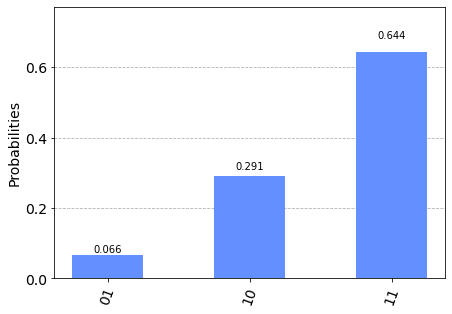

In [17]:
backend = Aer.get_backend('qasm_simulator')
job = execute(qc, backend, shots=shots)
result = job.result()

counts = result.get_counts(qc)
print(f"counts: {counts}")
plot_histogram(counts)

In [18]:
amplitudes = { x:sqrt(counts[x]) for x in counts }

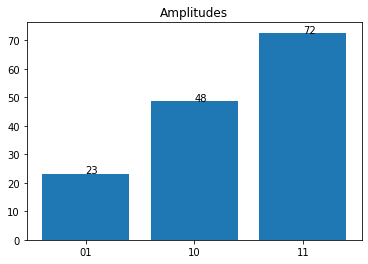

In [19]:
keys = [x for x in amplitudes.keys()]
keys.sort()
values = [amplitudes[x] for x in keys]
plt.bar(keys, values)
plt.title("Amplitudes")
for a,b in zip(keys, values): 
    plt.text(a, b, str(int(b)))
plt.show()

### Visualizations
https://qiskit.org/documentation/tutorials/circuits/2_plotting_data_in_qiskit.html

In [20]:
qc = amplitude_encoding_circuit()
backend = BasicAer.get_backend('statevector_simulator')
result = execute(qc, backend).result()
psi = result.get_statevector(qc)

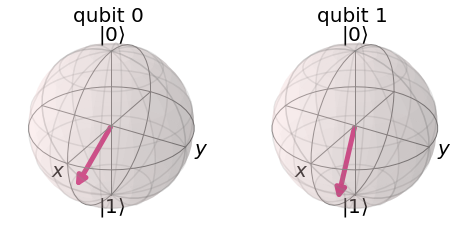

In [21]:
plot_bloch_multivector(psi)

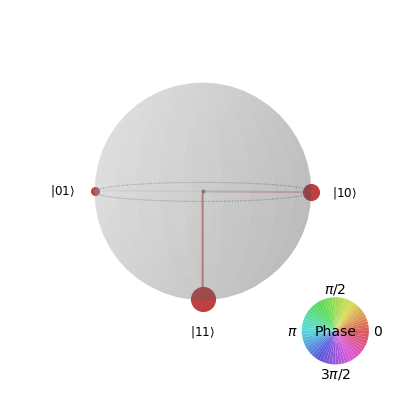

In [22]:
plot_state_qsphere(psi)

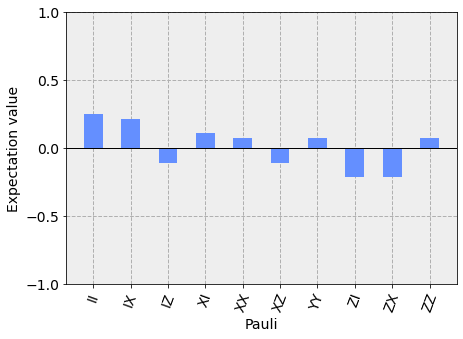

In [23]:
plot_state_paulivec(psi)

## Log-Normal Distribution
https://quantumcomputinguk.org/tutorials/modelling-probability-distributions-in-qiskit

In [24]:
mu = 0
sigma = 0.25
mean = np.exp(mu + sigma**2/2)
variance = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
stddev = np.sqrt(variance)

# Limit range to [-3; +3] std dev
low  = np.maximum(0, mean - 3*stddev)
high = mean + 3*stddev

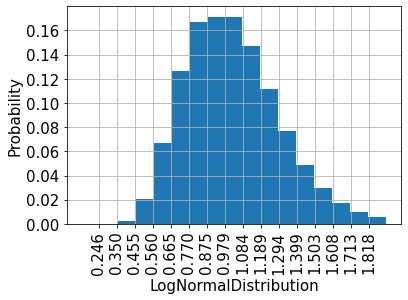

In [25]:
model = LogNormalDistribution(qubits, mu=mu, sigma=sigma**2, bounds=(low, high))
x = model.values
y = model.probabilities
plt.bar(x, y, width=0.2)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.grid()
plt.xlabel('LogNormalDistribution', size=15)
plt.ylabel('Probability', size=15)
plt.show()

In [26]:
#model.decompose().draw()

## European Option Payoff
https://qiskit.org/documentation/finance/tutorials/03_european_call_option_pricing.html

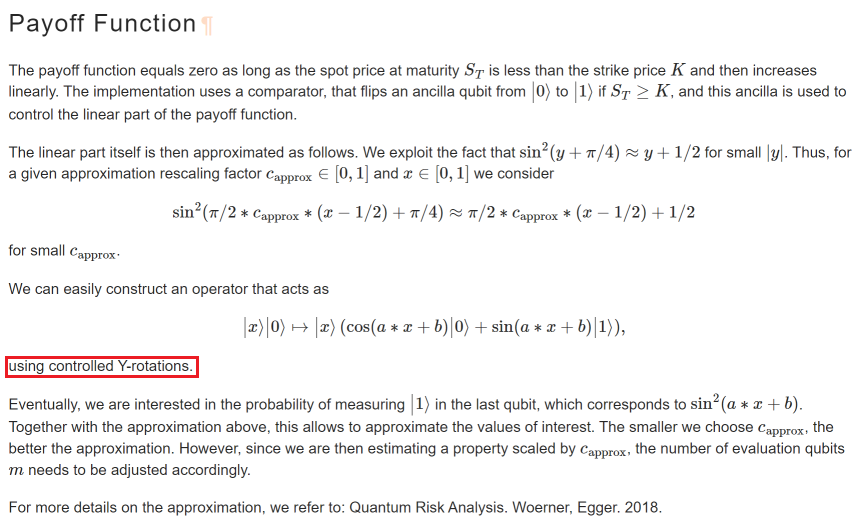

## Linear Amplitude
`LinearAmplitudeFunction`: A circuit implementing a (piecewise) linear function on qubit amplitudes. 🙌

In [27]:
from qiskit.circuit.library import LinearAmplitudeFunction

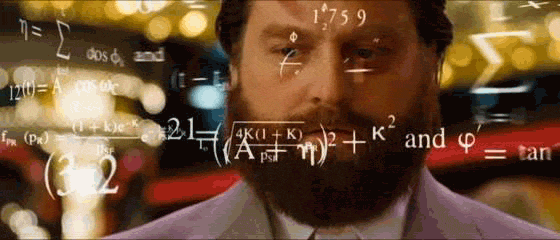